# 🏠 Irish Residential Property Price Register - Market Analysis

## Overview
This notebook analyses all residential property sales in Ireland from 2010 to present 
using data from the official Property Price Register (propertypriceregister.ie).

## Objectives
- Understand how Irish property prices have changed since 2010
- Compare Dublin prices against the national average
- Identify county-level price trends
- Analyse property type distribution across Ireland

## Dataset
- **Source:** propertypriceregister.ie
- **Coverage:** All residential property transactions in Ireland
- **Records:** 700,000+ sales since January 2010
- **Author:** Navya Zacharia

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## Step 1 - Load the Data

We load the raw CSV using `latin-1` encoding because the file contains special 
characters (euro signs, Irish place names with accents) that standard UTF-8 cannot read.

In [23]:
df = pd.read_csv('PPR-ALL.csv', encoding='latin-1')
print(f"Total records: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Total records: 789,184
Total columns: 9

Columns: ['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (\x80)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,01/01/2010,"5 Braemor Drive, Churchtown, Co.Dublin",Dublin,NaN,"343,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,03/01/2010,"134 Ashewood Walk, Summerhill Lane, Portlaoise",Laois,NaN,"185,000.00",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
2,04/01/2010,"1 Meadow Avenue, Dundrum, Dublin 14",Dublin,NaN,"438,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN
3,04/01/2010,"1 The Haven, Mornington",Meath,NaN,"400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
4,04/01/2010,"11 Melville Heights, Kilkenny",Kilkenny,NaN,"160,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


## Step 2 - Data Cleaning

The raw dataset has several issues we need to fix before analysis:

- **Price column** contains a currency symbol and commas (e.g. `343,000.00`) - needs to be converted to numeric
- **Date column** is stored as a string - needs to be converted to datetime format
- **County names** have inconsistent whitespace - need standardising
- **Non-market transactions** flagged as "Not Full Market Price = Yes" are removed to ensure accurate market analysis

After cleaning we retain 748,996 records out of 789,184 - a removal of 40,188 non-market transactions.

In [24]:
# Reload fresh
df = pd.read_csv('PPR-ALL.csv', encoding='latin-1')

# Fix price - remove \x80 (euro sign), commas, spaces
df['Price'] = df.iloc[:, 4].str.replace('\x80', '').str.replace(',', '').str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Fix date
df['Date'] = pd.to_datetime(df['Date of Sale (dd/mm/yyyy)'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Fix county
df['County'] = df['County'].str.strip().str.title()

# Fix Not Full Market Price
df['Not Full Market Price'] = df['Not Full Market Price'].str.strip()

# Filter
df_clean = df[df['Not Full Market Price'] == 'No'].copy()
df_clean = df_clean.dropna(subset=['Price', 'Date'])

print(f"Records before cleaning: {df.shape[0]:,}")
print(f"Records after cleaning: {df_clean.shape[0]:,}")
print(f"Year range: {df_clean['Year'].min()} - {df_clean['Year'].max()}")
print(f"Counties: {df_clean['County'].nunique()}")
print(f"Price min: €{df_clean['Price'].min():,.0f}")
print(f"Price max: €{df_clean['Price'].max():,.0f}")
print(f"Price median: €{df_clean['Price'].median():,.0f}")

Records before cleaning: 789,184
Records after cleaning: 748,996
Year range: 2010 - 2026
Counties: 26
Price min: €5,031
Price max: €387,665,198
Price median: €247,500


### Cleaning Results

- Records retained: **748,996** out of 789,184
- Records removed: **40,188** non-market price transactions
- Year range: **2010 to 2026**
- Counties covered: **26** (all Irish counties)
- Median property price across all years: **€247,500**
- Price range: **€5,031** to **€387,665,198**

The data is now clean and ready for analysis. The maximum price of €387m is unusually high and likely represents a commercial property mislabelled as residential - we will apply a price cap in the analysis to remove outliers.

### Outlier Removal

In [25]:
# Remove extreme outliers - cap at €5m as reasonable max for residential property
df_clean = df_clean[df_clean['Price'] <= 5000000].copy()

print(f"Records after removing outliers: {df_clean.shape[0]:,}")
print(f"New price max: €{df_clean['Price'].max():,.0f}")
print(f"New price median: €{df_clean['Price'].median():,.0f}")

Records after removing outliers: 748,051
New price max: €5,000,000
New price median: €247,000



Properties priced above €5,000,000 were removed as they are unlikely to represent 
standard residential transactions. This ensures our trend analysis reflects the 
typical Irish housing market rather than extreme outliers.

## Step 3 - Exploratory Analysis

With the cleaned dataset we now explore key dimensions of the Irish 
housing market using visualisations and statistical summaries.

###  Plot 1 - National Median Price Trend.

This chart tracks the national median property price in Ireland from 2010 to 2026. 
The median is used instead of the average to avoid distortion from extremely high 
value sales. This gives us a clearer picture of what a typical Irish buyer paid 
in any given year.

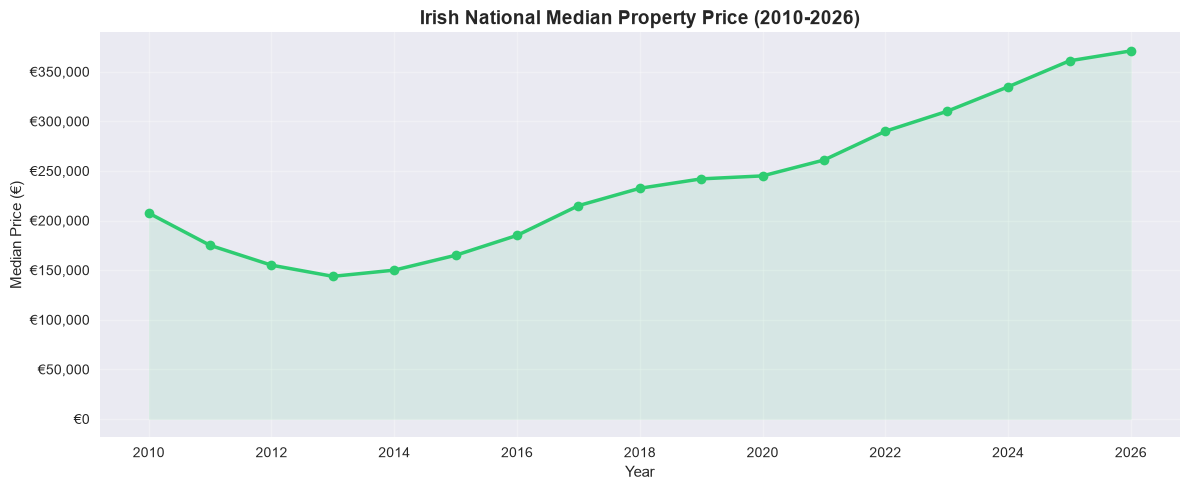

In [26]:
# Group the cleaned data by year and calculate the median price for each year
yearly = df_clean.groupby('Year')['Price'].median().reset_index()

# Rename columns to readable columns
yearly.columns = ['Year', 'Median Price']

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Median Price'], marker='o', linewidth=2.5, color='#2ecc71')
plt.fill_between(yearly['Year'], yearly['Median Price'], alpha=0.1, color='#2ecc71')
plt.title('Irish National Median Property Price (2010-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Price (€)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('national_price_trend.png', dpi=150)
plt.show()

The chart reveals a clear story of crash, recovery, and sustained growth in the Irish property market:

- **2010:** National median price started at approximately €210,000
- **2011-2013:** Prices continued falling, hitting a post-crash low of around €145,000 in 2013 - a drop of over 30% from 2010
- **2014-2019:** Steady recovery as the Irish economy bounced back, driven by multinational investment and strong employment growth
- **2020:** Price growth paused slightly due to COVID-19 but the market remained resilient unlike the 2008 crash
- **2021-2026:** Prices accelerated sharply, reaching approximately €370,000 in 2026 - more than double the 2013 low

The consistent upward trend since 2013 with no sign of correction reflects Ireland's 
chronic housing supply shortage. Despite repeated government commitments to increase 
housing output, demand has consistently outpaced supply, pushing prices higher every year.

### Plot 2 - Property Type Distribution

This analysis breaks down all 748,996 transactions by property type. 
Understanding the split between new builds and second-hand properties 
is important because it reflects the health of Ireland's construction 
sector and the availability of new housing stock in the market.

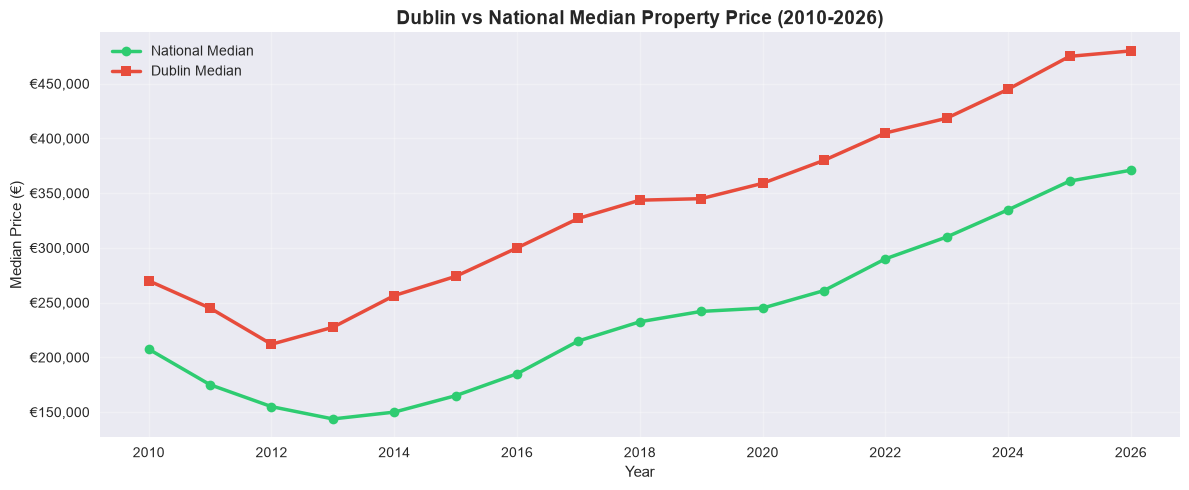

Dublin vs National gap in 2026: €109,000


In [27]:

# Filter down to Dublin only and get the median price for each year
dublin = df_clean[df_clean['County'] == 'Dublin'].groupby('Year')['Price'].median()

# Get the national median price for each year across all 26 counties
national = df_clean.groupby('Year')['Price'].median()

plt.figure(figsize=(12, 5))
plt.plot(national.index, national.values, marker='o', linewidth=2.5,
         label='National Median', color='#2ecc71')
plt.plot(dublin.index, dublin.values, marker='s', linewidth=2.5,
         label='Dublin Median', color='#e74c3c')
plt.title('Dublin vs National Median Property Price (2010-2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Price (€)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dublin_vs_national.png', dpi=150)
plt.show()

latest_year = dublin.index.max()
gap = dublin[latest_year] - national[latest_year]
print(f"Dublin vs National gap in {latest_year}: €{gap:,.0f}")

The chart clearly shows that Dublin has always been more expensive than the 
national median, and that gap has widened significantly since 2014:

- **2010:** Dublin median was approximately €270,000 vs national €210,000 - a gap of €60,000
- **2012:** Both markets hit their post-crash low simultaneously, with Dublin at €215,000 and national at €155,000
- **2014-2019:** Dublin recovered much faster than the rest of Ireland, driven by the concentration of tech multinationals creating high-paying jobs in the capital
- **2020-2021:** The gap narrowed slightly as remote working allowed buyers to consider properties outside Dublin
- **2026:** Dublin median reached approximately €480,000 vs national €370,000 - a gap of **€109,000**

The widening Dublin premium reflects the uneven distribution of employment 
across Ireland. Until major employers establish significant operations outside 
Dublin, demand for Dublin properties will continue to outpace supply and 
keep prices elevated well above the national average.

### Plot 3 - Top 10 Most Expensive Counties

Not all of Ireland's 26 counties are equal when it comes to property prices. 
This chart shows the 10 most expensive counties based on median sale price 
in the most recent year, giving a snapshot of where property is least 
affordable right now.

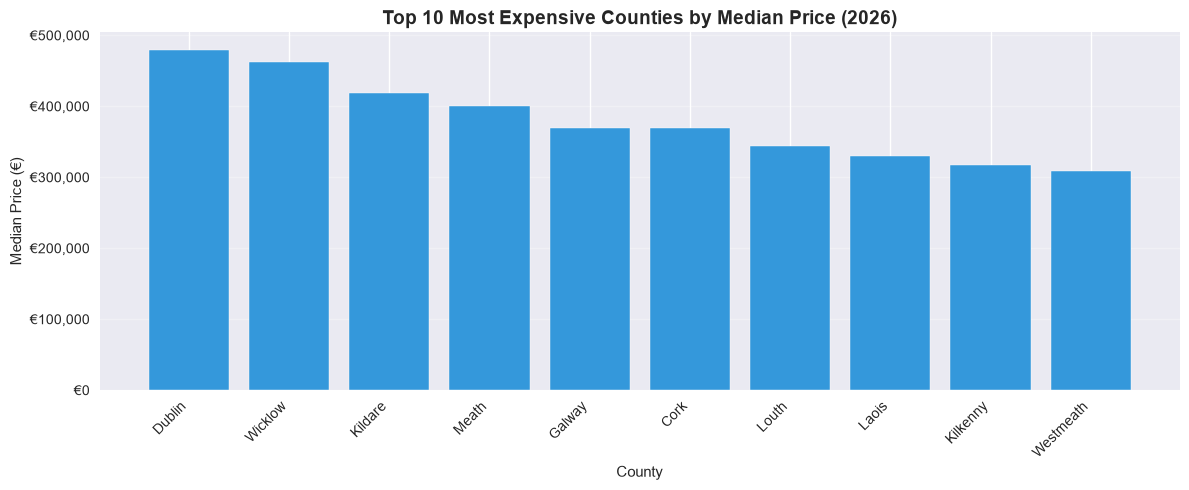

In [28]:
# Filter to only the most recent year in the dataset
latest = df_clean[df_clean['Year'] == df_clean['Year'].max()]

# Calculate median price per county and take the top 10 most expensive
county_prices = latest.groupby('County')['Price'].median().sort_values(ascending=False).head(10)


plt.figure(figsize=(12, 5))
bars = plt.bar(county_prices.index, county_prices.values, color='#3498db', edgecolor='white')
plt.title(f'Top 10 Most Expensive Counties by Median Price ({df_clean["Year"].max()})',
          fontsize=14, fontweight='bold')
plt.xlabel('County')
plt.ylabel('Median Price (€)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('county_comparison.png', dpi=150)
plt.show()

The chart confirms Dublin's dominance but also highlights the strength of the 
Greater Dublin Area commuter belt counties:

- **Dublin** is the most expensive county at approximately **€480,000** median price
- **Wicklow** comes in second at approximately **€460,000** - driven by its proximity 
to Dublin and attractive coastal locations
- **Kildare** and **Meath** follow at approximately **€415,000** and **€400,000** 
respectively - both popular commuter counties with good motorway and rail links to Dublin
- **Galway** and **Cork** represent Ireland's two other major cities, both sitting 
around **€365,000** - significantly cheaper than Dublin but expensive relative to 
the national median
- **Westmeath** is the most affordable in the top 10 at approximately **€305,000**

The dominance of Dublin and its surrounding commuter counties in the top 10 
reflects how the Irish property market is heavily shaped by proximity to Dublin's 
employment centres. Buyers priced out of Dublin are pushing up prices in 
Wicklow,

### Plot 4 - Property Type Distribution

The Property Price Register records two main types of residential properties:

- **Second-Hand** - previously owned properties being resold
- **New Build** - newly constructed properties sold for the first time

A small number of records (47) are entered in Irish (Gaeilge) as 
"Teach/Arasan Conaithe" - these represent the same categories and have 
been merged into their English equivalents for analysis.

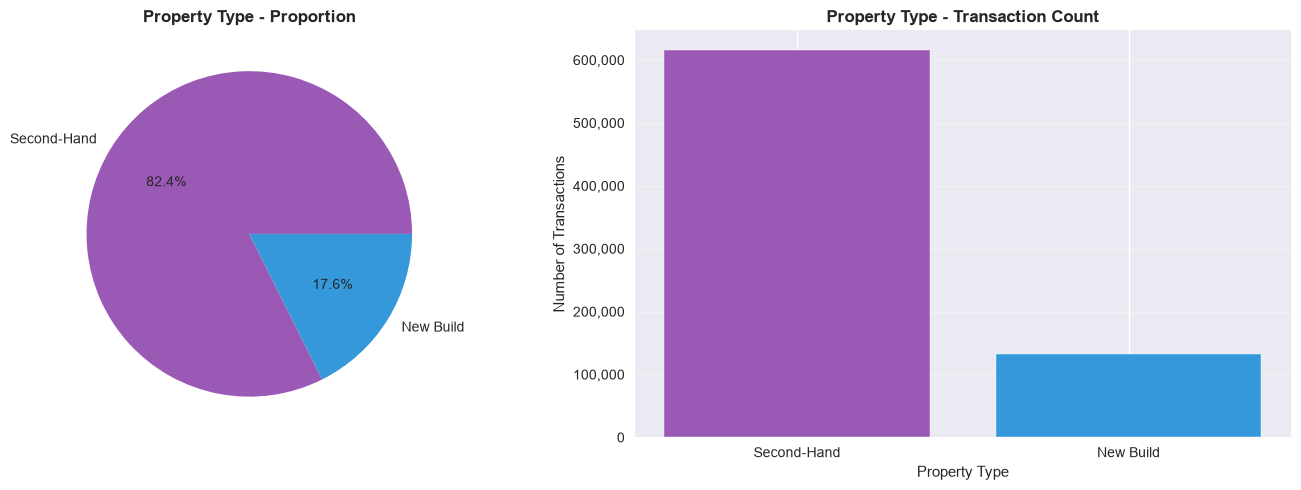

Property Type
Second-Hand    616259
New Build      131792
Name: count, dtype: int64


In [29]:
# Merge all Irish language entries into main categories
df_clean['Property Type'] = df_clean['Description of Property'].str.strip()
df_clean['Property Type'] = df_clean['Property Type'].replace({
    'Second-Hand Dwelling house /Apartment': 'Second-Hand',
    'New Dwelling house /Apartment': 'New Build',
    'Teach/Árasán Cónaithe Atháimhe': 'Second-Hand',
    'Teach/Árasán Cónaithe Nua': 'New Build',
    'Teach/?ras?n C?naithe Nua': 'New Build'
})

prop_type = df_clean['Property Type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - proportion
ax1.pie(prop_type.values, labels=prop_type.index, autopct='%1.1f%%',
        colors=['#9b59b6', '#3498db'])
ax1.set_title('Property Type - Proportion', fontweight='bold')

# Bar chart
ax2.bar(prop_type.index, prop_type.values, color=['#9b59b6', '#3498db'], edgecolor='white')
ax2.set_title('Property Type - Transaction Count', fontweight='bold')
ax2.set_ylabel('Number of Transactions')
ax2.set_xlabel('Property Type')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('property_type.png', dpi=150)
plt.show()

print(prop_type)

The Irish housing market is heavily dominated by second-hand properties:

- **Second-Hand properties** account for **82.4%** of all transactions (616,259 sales)
- **New Builds** account for only **17.6%** of transactions (131,792 sales)

This significant imbalance reflects Ireland's chronic shortage of new housing 
supply. For every 1 new home built and sold, approximately 4.7 second-hand 
properties change hands. 

This has two major consequences for the market:
- Buyers are competing heavily for a limited pool of existing stock, pushing 
prices upward
- First-time buyers relying on the Help to Buy scheme (which only applies to 
new builds) have a very limited selection to choose from

Despite repeated government targets to increase housing output, new builds 
have consistently failed to make up a larger share of the market over the 
16 year period analysed.

### Plot 5 - Number of Transactions per Year

Price alone does not tell the full story of the Irish housing market. 
The number of transactions per year shows us how active the market was 
and reveals the impact of major economic events such as the 2008 financial 
crash, COVID-19 restrictions, and the current housing crisis on buyer activity.

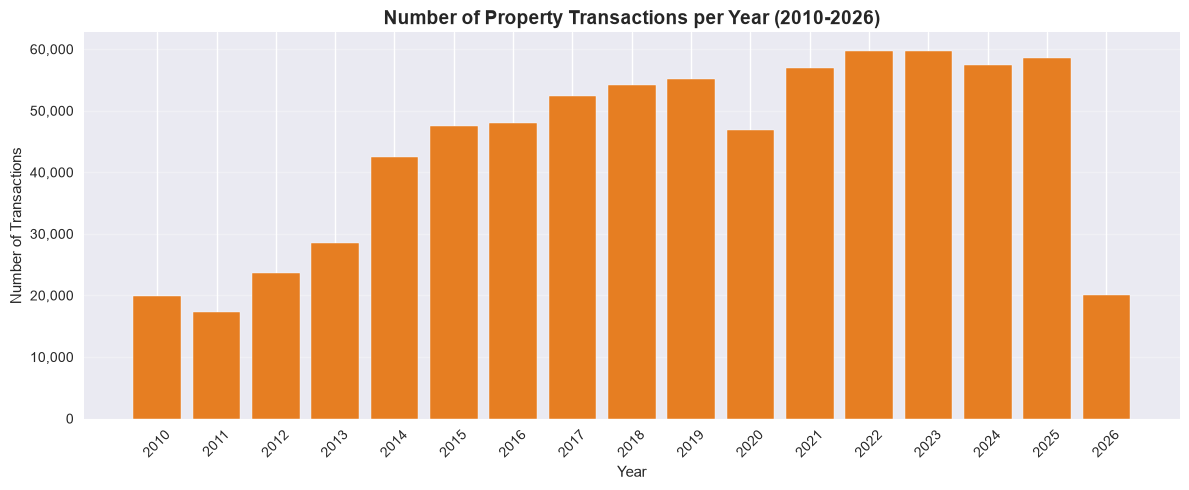

    Year  Transactions
0   2010         19899
1   2011         17344
2   2012         23664
3   2013         28475
4   2014         42526
5   2015         47478
6   2016         47972
7   2017         52315
8   2018         54102
9   2019         55205
10  2020         46810
11  2021         56904
12  2022         59724
13  2023         59623
14  2024         57350
15  2025         58625
16  2026         20035


In [30]:
# Count how many properties were sold in each year
transactions = df_clean.groupby('Year')['Price'].count().reset_index()
# Rename columns to readable columns
transactions.columns = ['Year', 'Transactions']


# Convert year to integer 
transactions['Year'] = transactions['Year'].astype(int)

plt.figure(figsize=(12, 5))
plt.bar(transactions['Year'], transactions['Transactions'],
        color='#e67e22', edgecolor='white')
plt.title('Number of Property Transactions per Year (2010-2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Force x-axis to show every year as a whole number
plt.xticks(transactions['Year'], rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(transactions)


The transaction volume data tells a compelling story about Irish market confidence:

- **2010-2011:** Low activity (19,899 and 17,344 transactions) as the market 
was still in shock following the financial crash and negative equity was widespread
- **2012-2014:** Gradual recovery in buyer confidence as the economy stabilised 
and the IMF bailout programme concluded successfully
- **2015-2019:** Strong and sustained growth in transaction volumes, peaking at 
**55,205 transactions in 2019** - the highest pre-COVID figure
- **2020:** A sharp drop to **46,810 transactions** due to COVID-19 lockdowns 
restricting viewings, valuations, and completions
- **2021-2023:** Rapid recovery with volumes hitting a record **59,724 in 2022** 
and staying consistently above 57,000 through 2025
- **2026:** Only **20,035 transactions** recorded - this is expected as 2026 
data is only partial (up to June)

The sustained high transaction volumes since 2021 despite record prices 
indicates extremely strong underlying demand that continues to outpace supply.

### Plot 6 - County Level Analysis

This chart compares median property prices across all 26 Irish counties 
using the most recent year of data. Dublin is highlighted in red to show 
how it compares against every other county. This gives a clear picture of 
regional affordability across Ireland.

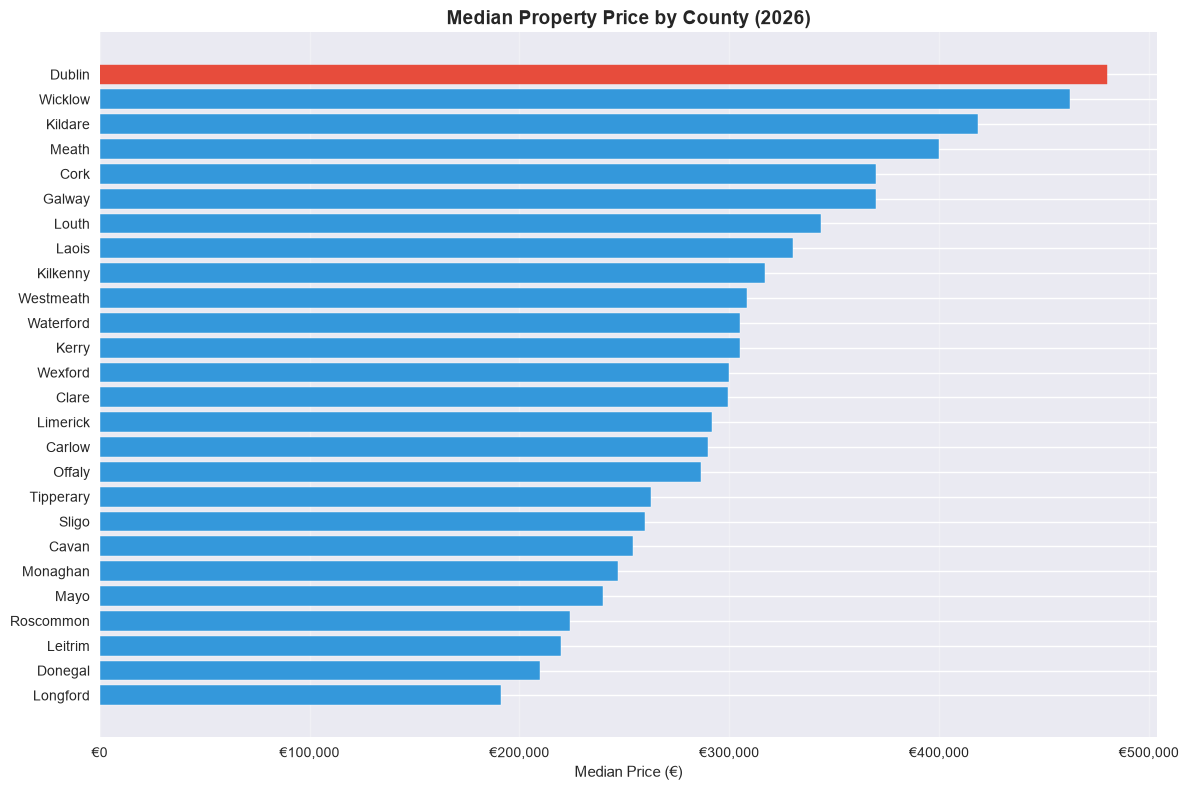


Most expensive county: Dublin - €480,000
Most affordable county: Longford - €191,000
Price gap: €289,000


In [31]:
# Get the most recent year in the dataset
latest_year = df_clean['Year'].max()

# Calculate median price per county for the most recent year and sort lowest to highest
county_prices = (df_clean[df_clean['Year'] == latest_year]
                 .groupby('County')['Price']
                 .median()
                 .sort_values(ascending=True))

plt.figure(figsize=(12, 8))
bars = plt.barh(county_prices.index, county_prices.values,
                color='#3498db', edgecolor='white')

# Highlight Dublin in red so it stands out from other counties
dublin_idx = list(county_prices.index).index('Dublin')
bars[dublin_idx].set_color('#e74c3c')

plt.title(f'Median Property Price by County ({latest_year})',
          fontsize=14, fontweight='bold')
plt.xlabel('Median Price (€)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\nMost expensive county: {county_prices.index[-1]} - €{county_prices.iloc[-1]:,.0f}")
print(f"Most affordable county: {county_prices.index[0]} - €{county_prices.iloc[0]:,.0f}")
print(f"Price gap: €{county_prices.iloc[-1] - county_prices.iloc[0]:,.0f}")


The chart reveals dramatic regional price differences across Ireland's 26 counties:

- **Dublin** is the most expensive county at **€480,000** - highlighted in 
red and clearly ahead of every other county
- **Wicklow** comes second at approximately **€460,000** - driven by its 
proximity to Dublin and attractive coastal locations along the M11 corridor
- **Kildare and Meath** follow at approximately **€420,000** and **€400,000** 
respectively - both popular commuter counties with strong motorway and rail 
connections to Dublin city centre
- **Cork and Galway** represent Ireland's second and third cities, both 
sitting around **€370,000**
- **Longford** is the most affordable county at **€191,000** - less than 
half the price of Dublin

The price gap between Dublin and Longford is **€289,000** - meaning a buyer 
in Longford can purchase a property for what a Dublin buyer would pay as a 
deposit. This dramatic inequality reflects the extreme concentration of 
employment and investment in Dublin relative to the rest of Ireland, and 
highlights why remote working policy has such significant implications for 
the Irish property market.

### Plot 7 - Dublin vs National Price Comparison

Dublin has historically commanded a significant premium over the rest of Ireland. 
This chart tracks how the gap between Dublin and the national median price has 
evolved since 2010, and whether that premium is growing or narrowing over time. 
The shaded area represents the Dublin premium - the extra cost of buying in 
the capital compared to the national average.

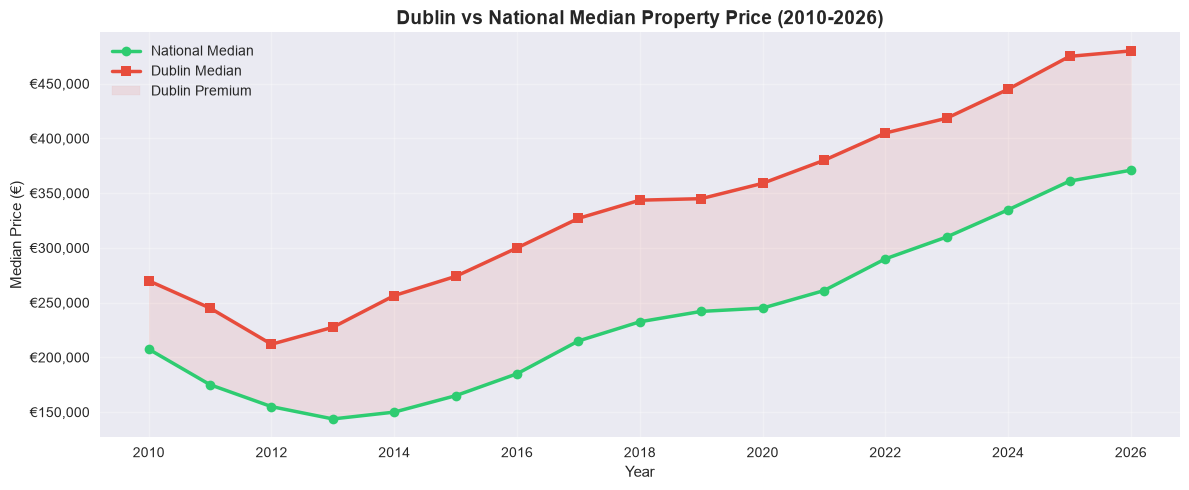

Dublin vs National gap in 2026: €109,000
Dublin median (2026): €480,000
National median (2026): €371,000


In [32]:

# Filter to Dublin only and calculate median price per year
dublin = df_clean[df_clean['County'] == 'Dublin'].groupby('Year')['Price'].median()

# Calculate national median price per year across all 26 counties
national = df_clean.groupby('Year')['Price'].median()

plt.figure(figsize=(12, 5))
plt.plot(national.index, national.values, marker='o', linewidth=2.5,
         label='National Median', color='#2ecc71')
plt.plot(dublin.index, dublin.values, marker='s', linewidth=2.5,
         label='Dublin Median', color='#e74c3c')
plt.fill_between(dublin.index, national.values, dublin.values, 
                 alpha=0.1, color='#e74c3c', label='Dublin Premium')
plt.title('Dublin vs National Median Property Price (2010-2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Price (€)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

latest_year = dublin.index.max()
gap = dublin[latest_year] - national[latest_year]
print(f"Dublin vs National gap in {latest_year}: €{gap:,.0f}")
print(f"Dublin median ({latest_year}): €{dublin[latest_year]:,.0f}")
print(f"National median ({latest_year}): €{national[latest_year]:,.0f}")



The shaded area between the two lines tells the story of the growing Dublin premium:

- **2010:** Dublin median was **€270,000** vs national **€210,000** - 
a gap of €60,000 even before the full crash played out
- **2012:** Both markets hit their post-crash low simultaneously, with 
Dublin at **€215,000** and national at **€155,000** - the gap narrowed 
to just €60,000 as Dublin fell harder in percentage terms
- **2014-2019:** Dublin recovered much faster than the rest of Ireland, 
driven by the concentration of tech multinationals creating high-paying 
jobs in the capital. The shaded premium area visibly widens during this period
- **2020:** The gap narrowed slightly as remote working allowed buyers 
to consider properties outside Dublin for the first time
- **2026:** Dublin median reached **€475,000** vs national **€370,000** - 
a gap of **€109,000**

The consistently widening shaded area since 2014 is the most important 
visual in this analysis. It shows that Dublin is not just expensive - 
it is becoming increasingly expensive relative to the rest of Ireland. 
Until major employers establish significant operations outside Dublin, 
this premium is unlikely to narrow.

### Plot 8 - New Build vs Second-Hand Price Comparison

New builds and second-hand properties are priced very differently in Ireland. 
New builds often carry a premium due to modern construction standards, better 
energy ratings, and government schemes like Help to Buy which apply exclusively 
to new properties. This chart compares how prices for each type have evolved 
since 2010.

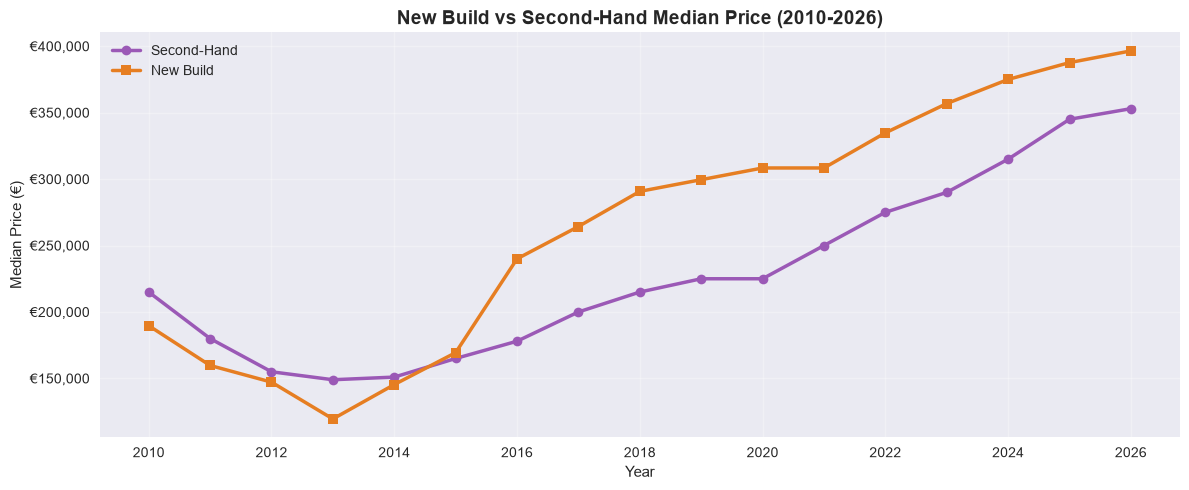

New Build median (2026): €396,476
Second-Hand median (2026): €353,000
New Build premium: €43,476


In [33]:
# Get median price per year for new builds only
new_build = df_clean[df_clean['Property Type'] == 'New Build'].groupby('Year')['Price'].median()

# Get median price per year for second-hand properties only
second_hand = df_clean[df_clean['Property Type'] == 'Second-Hand'].groupby('Year')['Price'].median()

plt.figure(figsize=(12, 5))
plt.plot(second_hand.index, second_hand.values, marker='o', linewidth=2.5,
         label='Second-Hand', color='#9b59b6')
plt.plot(new_build.index, new_build.values, marker='s', linewidth=2.5,
         label='New Build', color='#e67e22')
plt.title('New Build vs Second-Hand Median Price (2010-2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Price (€)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

latest_year = new_build.index.max()
print(f"New Build median ({latest_year}): €{new_build[latest_year]:,.0f}")
print(f"Second-Hand median ({latest_year}): €{second_hand[latest_year]:,.0f}")
print(f"New Build premium: €{new_build[latest_year] - second_hand[latest_year]:,.0f}")

### Finding - New Build vs Second-Hand Price Comparison

The chart reveals an interesting divergence between new build and second-hand 
property prices since 2015:

- **2010-2014:** Second-hand properties were actually more expensive than new 
builds during the post-crash period, as new build construction almost completely 
stopped and developers sold remaining stock at heavily discounted prices
- **2015:** The two lines crossed - the point at which new builds began commanding 
a premium over second-hand properties for the first time
- **2016-2026:** New builds have consistently outpriced second-hand properties, 
with the gap widening steadily each year
- **2026:** New Build median reached **€396,476** vs Second-Hand **€353,000** - 
a new build premium of **€43,476**

The new build premium is driven by three factors:
- Modern energy efficiency standards (BER ratings) which reduce running costs
- The Help to Buy scheme which gives first-time buyers up to €30,000 toward 
a new build purchase, effectively inflating new build prices
- Higher construction costs due to labour and material price increases since 2020

The crossing of the two lines in 2015 marks a significant turning point in 
the Irish market - the moment when new housing supply became genuinely scarce 
and developers regained pricing power.

## Summary of Key Findings

This section brings together all the key statistics from our analysis 
into a single reference table, giving a concise overview of the Irish 
property market from 2010 to 2026.

In [34]:
# Pull together all the key numbers from our analysis into one summary table
summary = {
    'Total Transactions Analysed': f"{df_clean.shape[0]:,}",
    'Year Range': f"{df_clean['Year'].min()} - {df_clean['Year'].max()}",
    'Counties Covered': f"{df_clean['County'].nunique()}",
    'National Median Price (Latest Year)': f"€{df_clean[df_clean['Year'] == df_clean['Year'].max()]['Price'].median():,.0f}",
    'Dublin Median Price (Latest Year)': f"€{df_clean[(df_clean['County'] == 'Dublin') & (df_clean['Year'] == df_clean['Year'].max())]['Price'].median():,.0f}",
    'Most Expensive County': county_prices.index[-1],
    'Most Affordable County': county_prices.index[0],
    'Second-Hand Share of Market': f"{(df_clean['Property Type'] == 'Second-Hand').sum() / df_clean.shape[0] * 100:.1f}%",
    'New Build Share of Market': f"{(df_clean['Property Type'] == 'New Build').sum() / df_clean.shape[0] * 100:.1f}%",
}

print("=" * 55)
print("   IRISH PROPERTY MARKET - KEY FINDINGS SUMMARY")
print("=" * 55)
for key, value in summary.items():
    print(f"{key:<45} {value}")
print("=" * 55)

   IRISH PROPERTY MARKET - KEY FINDINGS SUMMARY
Total Transactions Analysed                   748,051
Year Range                                    2010 - 2026
Counties Covered                              26
National Median Price (Latest Year)           €371,000
Dublin Median Price (Latest Year)             €480,000
Most Expensive County                         Dublin
Most Affordable County                        Longford
Second-Hand Share of Market                   82.4%
New Build Share of Market                     17.6%


## Conclusion

This analysis of 748,051 residential property transactions from Ireland's 
Property Price Register reveals five critical trends in the Irish housing market:

1. **Price Recovery Post-Crash** - The national median price hit a low of 
approximately €145,000 in 2013 following the 2008 financial crisis and has 
since more than doubled to €371,000 in 2026 - a 156% increase in 13 years

2. **Dublin Premium** - Dublin consistently commands a €109,000 premium over 
the national median (€480,000 vs €371,000), driven by the concentration of 
multinational employers and chronic housing supply shortages in the capital

3. **Regional Inequality** - There is a €289,000 price gap between the most 
expensive county (Dublin at €480,000) and the most affordable (Longford at 
€191,000), reflecting uneven economic development across Ireland

4. **Supply Crisis** - Second-hand properties account for 82.4% of all 
transactions, indicating that new housing construction has consistently 
failed to keep pace with demand - a core driver of rising prices

5. **New Build Premium** - New builds command a €43,476 premium over 
second-hand properties in 2026, partly driven by the Help to Buy scheme 
which effectively inflates new build prices by subsidising buyer deposits
